In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import json
import torch

plt.rcParams["font.size"]=16
plt.rcParams["figure.dpi"] = 300

### Inference

In [232]:
import torch
from Model.KAN_C import KAN
from Model.KAN_C import init_params

# from Model.KAN_RBF import KAN
# from Model.KAN_RBF import init_params
import argparse

device = 'cuda'
# model_dir = './checkpoints_PIKAN/' 

with open(model_dir + "config.json", "r") as f:
    config = json.load(f)

########################## cKAN ##############################
layers = [config["model"]["in_c"]] + config["model"]["num_layer"]*[config["model"]["width_layer"]]+ [config["model"]["out_c"]]
params = init_params(layers = layers, degree=config["model"]["degree"], initialization_type='normal') 


model = KAN(params = params, x_left=config["model"]["x_left"], x_right=config["model"]["x_right"], degree=config["model"]["degree"])
model.to(device)

######################## B-Spline KAN ########################
# from config_KAN_BSpline import get_config
# model_cfg = config["model"]
# config = get_config()

# layers = [model_cfg["in_c"]] + model_cfg["num_layer"]*[model_cfg["width_layer"]]+ [model_cfg["out_c"]]
# model = KAN(layers_hidden=layers, grid_size=model_cfg["grid_size"] ,spline_order=model_cfg["spline_order"], \
#     x_left=model_cfg["x_left"], x_right=model_cfg["x_right"])
# model.to(device)

################################ RBF KAN #################################
# from config_KAN_RBF import get_config
# model_cfg = config["model"]

# hidden_layers =  model_cfg["num_layer"]*[model_cfg["width_layer"]]
# model = KAN(in_dim=model_cfg["in_c"], hidden_dims=hidden_layers, out_dim=model_cfg["out_c"] , degree=model_cfg["degree"], \
#     grid_min=model_cfg["grid_min"], grid_max=model_cfg["grid_max"], x_left=model_cfg["x_left"], x_right=model_cfg["x_right"])
# model.to(device)


# checkpoint_dir = './checkpoints_PIKAN/model_epoch20000.pth'   ##### C7_KAN
model.load_state_dict(torch.load(checkpoint_dir))

/tmp/ipykernel_3070803/3024032040.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_dir))


<All keys matched successfully>

In [122]:
from Model.NN1 import NN_Periodic
import json


# model_dir = './checkpoints_PINN/' 

with open(model_dir + "config.json", "r") as f:
    config = json.load(f)

model = NN_Periodic(config["model"]["in_c"], config["model"]["out_c"], config["model"]["features"],config["model"]["activation"],\
                   config["model"]["num_frequencies"],config["model"]["fourier_type"], config["model"]["fourier_scale"], config["model"]["use_siren"],\
                   config["model"]["siren_w0"], config["model"]["x_left"],config["model"]["x_right"],config["model"]["skip_con"])

# checkpoint_dir = './checkpoints_PINN/model_epoch20000.pth'   

model.load_state_dict(torch.load(checkpoint_dir))
device = 'cuda'
model.to(device)

/tmp/ipykernel_2691986/1244842583.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_dir))


NN_Periodic(
  (fourier_layer): RandomFourierFeatureLayer()
  (layers): ModuleList(
    (0): SIRENLayer(
      (linear): Linear(in_features=3, out_features=100, bias=True)
    )
    (1-5): 5 x SIRENLayer(
      (linear): Linear(in_features=100, out_features=100, bias=True)
    )
  )
  (final_layer): Linear(in_features=100, out_features=1, bias=True)
)

### Visualiztion of predictions

In [123]:
data_dir = '/users/skhodaka/data/skhodaka/PIKAN_PINN_other/Kdv/data/data1/'
domain_data = np.load(data_dir + 'domain_data.npy')
GT = domain_data[:,-1]

with torch.no_grad():
    preds = model(torch.tensor(domain_data[:,[0,1]], device=device).float()).cpu().numpy()

In [125]:
preds_reshape = preds.reshape(510,200)
GT_reshape = GT.reshape(510,200)
print("preds.shape:",preds_reshape.shape)
print("GT.shape:",GT_reshape.shape)

preds.shape: (510, 200)
GT.shape: (510, 200)


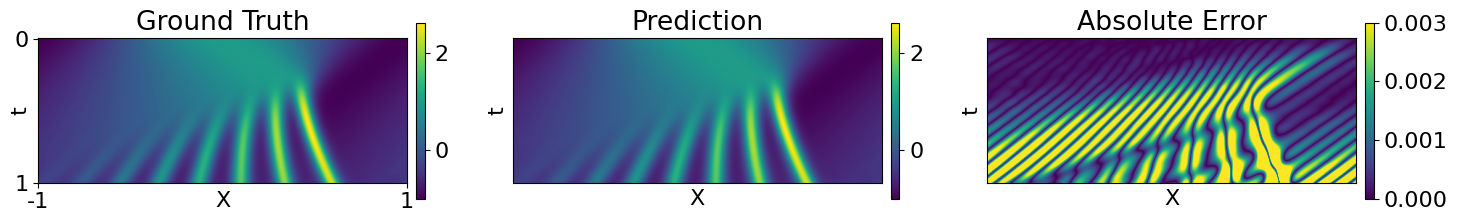

In [127]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

###############################################
# 1. Ground Truth
###############################################
im0 = ax[0].imshow(GT_reshape.T, origin='upper')

# Custom ticks
ax[0].set_xticks([0, GT_reshape.shape[0]-1])
ax[0].set_xticklabels(['-1', '1'])

ax[0].set_yticks([0, GT_reshape.shape[1]-1])
ax[0].set_yticklabels(['0', '1'])

ax[0].tick_params(axis='both', pad=3)   # very tight tick-label spacing

ax[0].xaxis.labelpad = -15
ax[0].yaxis.labelpad = -11

ax[0].set_xlabel('X')
ax[0].set_ylabel('t')

fig.colorbar(im0, ax=ax[0], shrink=0.5, pad=0.02)
ax[0].set_title('Ground Truth')

###################################################
# 2. Prediction
###################################################
im1 = ax[1].imshow(preds_reshape.T)
ax[1].set_xlabel('X')
ax[1].set_ylabel('t')
ax[1].set_xticks([])
ax[1].set_yticks([])
fig.colorbar(im1, ax=ax[1], shrink=0.5, pad=0.02)
ax[1].set_title('Prediction')


###################################################
# 3. Absolute Error (unchanged)
###################################################
im2 = ax[2].imshow(np.abs(GT_reshape - preds_reshape).T, vmin=0, vmax=0.003)
ax[2].set_xlabel('X')
ax[2].set_ylabel('t')
ax[2].set_xticks([])
ax[2].set_yticks([])
fig.colorbar(im2, ax=ax[2], shrink=0.5, pad=0.02)
ax[2].set_title('Absolute Error')

plt.tight_layout()
plt.show()

### Relative error

In [129]:
rel_error = np.linalg.norm(preds_reshape - GT_reshape)/np.linalg.norm(GT_reshape)
print("rel_error:",rel_error)

rel_error: 0.002561573087256191


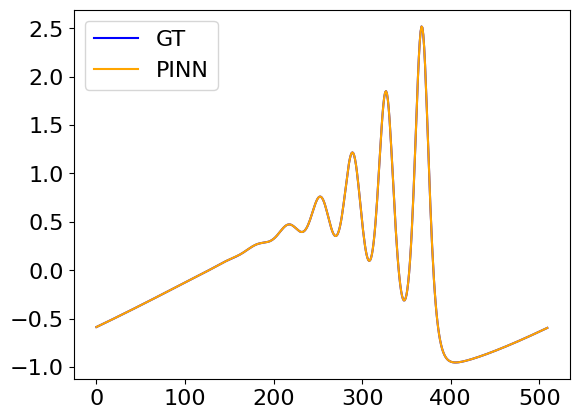

In [17]:
plt.plot(GT_reshape[:,100], color='blue', label='GT')
plt.plot(preds_reshape[:,100], color='orange', label='PINN')

plt.legend()

### Initial condition

In [15]:
initial_data = np.load(data_dir + 'initial_data.npy')
print("initial_data.shape:",initial_data.shape)

with torch.no_grad():
    preds = model(torch.tensor(initial_data[:,[0,1]], device=device).float()).squeeze().cpu().numpy()

print("preds.shape:",preds.shape)

initial_data.shape: (512, 3)
preds.shape: (512,)


Text(0, 0.5, 'u')

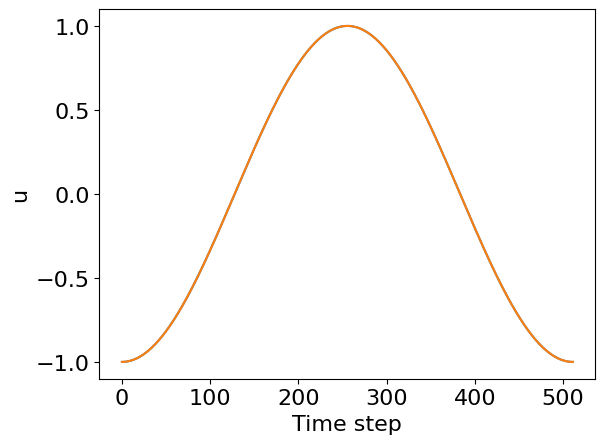

In [16]:
plt.plot(preds)
plt.plot(initial_data[:,-1])

plt.xlabel('Time step')
plt.ylabel('u')

In [44]:
### Relative error for initial condition

rel_initial = np.linalg.norm(preds - initial_data[:,-1])/np.linalg.norm(initial_data[:,-1])
print("initial condition relative error:",100*rel_initial)

initial condition relative error: 0.005077294686611123


#### Making a video of predictions

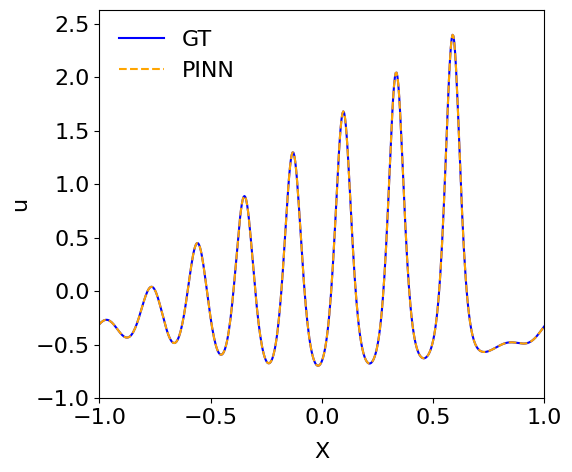

In [70]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np

# Define spatial domain from -1 to 1
x = np.linspace(-1, 1, GT_reshape.shape[0])

fig, ax = plt.subplots(figsize=(6, 5))
line1, = ax.plot([], [], color='blue', label='GT')
line2, = ax.plot([], [], color='orange',  linestyle='--', label='PINN')

# Set axis limits and labels
ax.set_xlim(-1, 1)
ax.set_ylim(np.min([GT_reshape, preds_reshape]), np.max([GT_reshape, preds_reshape]))
ax.set_xlabel("X", labelpad=10)  # extra padding to avoid clipping
ax.set_ylabel("u")
ax.set_xticks([-1, -0.5, 0, 0.5, 1])
ax.legend(frameon=False)
plt.tight_layout()

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    return line1, line2

def update(frame):
    # frame indexes the time axis (second axis)
    y1 = GT_reshape[:, frame]
    y2 = preds_reshape[:, frame]
    line1.set_data(x, y1)
    line2.set_data(x, y2)
    return line1, line2

# Create animation
anim = FuncAnimation(fig, update, frames=GT_reshape.shape[1], init_func=init, blit=True)

# Save as GIF (faster and portable)
writer = PillowWriter(fps=30)
anim.save('KdV.gif', writer=writer)

### Analysis in frequency domain

In [622]:
from scipy.signal import windows, coherence  # optional for coherence

def compare_spectra(gt, pred, fs=1.0, nfft=None, window='hann', plot_phase=False, plot=True):
    """
    Compare amplitude and (optionally) phase spectra of two 1D signals.
    Now amplitude and phase are aligned vertically in one figure.
    """
    assert gt.shape == pred.shape, "signals must have same shape"
    N = gt.size
    if nfft is None:
        nfft = N

    # window
    if window == 'hann':
        w = windows.hann(N, sym=False)
    elif window is None:
        w = np.ones(N)
    else:
        w = windows.get_window(window, N, fftbins=False)

    # apply window and remove mean
    gt_w = (gt - np.mean(gt)) * w
    pred_w = (pred - np.mean(pred)) * w

    # rFFT
    f = np.fft.rfftfreq(nfft, 1.0/fs)           # frequency axis
    G = np.fft.rfft(gt_w, n=nfft)
    P = np.fft.rfft(pred_w, n=nfft)

    # amplitude (magnitude) and phase
    ampG = np.abs(G) / (np.sum(w)/2)
    ampP = np.abs(P) / (np.sum(w)/2)
    phaseG = np.angle(G)
    phaseP = np.angle(P)

    # Metrics
    spec_l2 = np.linalg.norm(ampG - ampP)
    spec_rel = spec_l2 / (np.linalg.norm(ampG) + 1e-12)
    energyG = np.sum(ampG**2)
    energyP = np.sum(ampP**2)
    energy_ratio = energyP / (energyG + 1e-12)
    peak_idx_gt = np.argmax(ampG)
    peak_idx_pred = np.argmax(ampP)
    peak_freq_gt = f[peak_idx_gt]
    peak_freq_pred = f[peak_idx_pred]

    # ----- Plot amplitude and phase together -----
    if plot:
        if plot_phase:
            fig, axs = plt.subplots(2, 1, figsize=(7, 5), sharex=True, height_ratios=[1, 1])
        else:
            fig, axs = plt.subplots(1, 1, figsize=(7, 5))
            axs = [axs]  # make iterable
    
        # Amplitude spectrum
        axs[0].plot(f, ampG, label='GT', color='blue')
        axs[0].plot(f, ampP, label='Pred', color='orange', linestyle='--')
        axs[0].set_ylabel('Amplitude')
        axs[0].set_xlim(0, fs / 2)
        axs[0].set_title('Amplitude and Phase Spectra' if plot_phase else 'Amplitude Spectrum')
        axs[0].legend(frameon=False)
        axs[0].grid(True)
    
        # Phase spectrum
        if plot_phase:
            axs[1].plot(f, np.unwrap(phaseG), label='GT', color='blue')
            axs[1].plot(f, np.unwrap(phaseP), label='Pred', color='orange', linestyle='--')
            axs[1].set_xlabel('Frequency (Hz)')
            axs[1].set_ylabel('Phase (rad)')
            axs[1].grid(True)
    
        plt.tight_layout()
        plt.show()

    # ----- Print metrics -----
    # print(f"Spectral L2 error: {spec_l2:.6e}")
    # print(f"Relative spectral error: {spec_rel:.6e}")
    # print(f"GT energy: {energyG:.6e}, Pred energy: {energyP:.6e}, energy ratio Pred/GT = {energy_ratio:.4f}")
    # print(f"Peak freq GT = {peak_freq_gt:.4f} Hz (idx {peak_idx_gt}), Peak freq Pred = {peak_freq_pred:.4f} Hz (idx {peak_idx_pred})")

    return {
        'f': f, 'ampG': ampG, 'ampP': ampP,
        'phaseG': phaseG, 'phaseP': phaseP,
        'spec_l2': spec_l2, 'spec_rel': spec_rel,
        'energyG': energyG, 'energyP': energyP,
        'peak_freq_gt': peak_freq_gt, 'peak_freq_pred': peak_freq_pred
    }


loc: -0.607843137254902


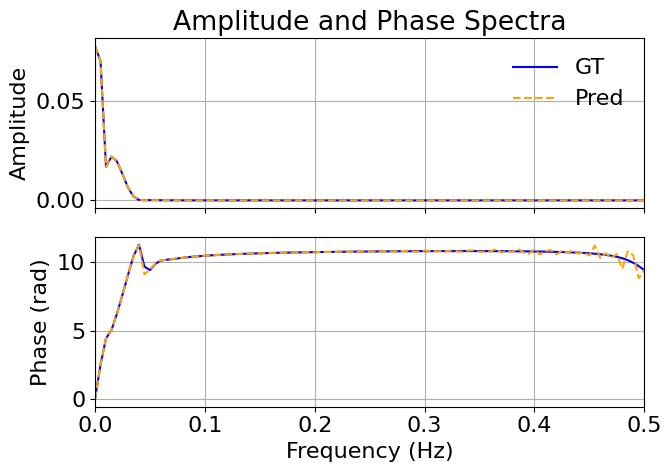

In [593]:
x_loc = 100
print("loc:", -1 + 2*x_loc/510)

res = compare_spectra(GT_reshape[x_loc,:], preds_reshape[x_loc,:], fs=1, plot_phase=True)

In [596]:
def compare_spectra_spatial(gt, pred, x=None, nfft=None, window='hann', plot_phase=False, plot=True):
    """
    Compare amplitude and (optionally) phase spectra of two 1D spatial signals.
    
    gt, pred : 1D numpy arrays (same length)
    x        : spatial coordinates corresponding to the signals (optional, default uniform 0..1)
    nfft     : length of FFT (zero-pad). If None, use len(gt)
    window   : 'hann' or None
    plot_phase : whether to plot phase spectra (unwrapped)
    """
    assert gt.shape == pred.shape, "signals must have same shape"
    N = gt.size
    if nfft is None:
        nfft = N

    # spatial grid
    if x is None:
        x = np.linspace(0, 1, N)
    dx = x[1] - x[0]

    # window
    if window == 'hann':
        w = windows.hann(N, sym=False)
    elif window is None:
        w = np.ones(N)
    else:
        w = windows.get_window(window, N, fftbins=False)

    # apply window and remove mean
    gt_w = (gt - np.mean(gt)) * w
    pred_w = (pred - np.mean(pred)) * w

    # FFT along spatial dimension
    k = np.fft.rfftfreq(nfft, d=dx)   # spatial frequency (cycles per unit length)
    G = np.fft.rfft(gt_w, n=nfft)
    P = np.fft.rfft(pred_w, n=nfft)

    # amplitude (magnitude) and phase
    ampG = np.abs(G) / (np.sum(w)/2)
    ampP = np.abs(P) / (np.sum(w)/2)
    phaseG = np.angle(G)
    phaseP = np.angle(P)

    # Metrics
    spec_l2 = np.linalg.norm(ampG - ampP)
    spec_rel = spec_l2 / (np.linalg.norm(ampG) + 1e-12)
    energyG = np.sum(ampG**2)
    energyP = np.sum(ampP**2)
    energy_ratio = energyP / (energyG + 1e-12)
    peak_idx_gt = np.argmax(ampG)
    peak_idx_pred = np.argmax(ampP)
    peak_freq_gt = k[peak_idx_gt]
    peak_freq_pred = k[peak_idx_pred]

    # ----- Plot amplitude and phase together -----
    if plot:
        if plot_phase:
            fig, axs = plt.subplots(2, 1, figsize=(7, 5), sharex=True, height_ratios=[1, 1])
        else:
            fig, axs = plt.subplots(1, 1, figsize=(7, 5))
            axs = [axs]  # make iterable
    
        # Amplitude spectrum
        axs[0].plot(k, ampG, label='GT', color='blue')
        axs[0].plot(k, ampP, label='Pred', color='orange', linestyle='--')
        axs[0].set_ylabel('Amplitude')
        axs[0].set_xlim(0, k.max())
        axs[0].set_title('Amplitude and Phase Spectra' if plot_phase else 'Amplitude Spectrum')
        axs[0].legend(frameon=False)
        axs[0].grid(True)
    
        # Phase spectrum
        if plot_phase:
            axs[1].plot(k, np.unwrap(phaseG), label='GT', color='blue')
            axs[1].plot(k, np.unwrap(phaseP), label='Pred', color='orange', linestyle='--')
            axs[1].set_xlabel('Spatial frequency')
            axs[1].set_ylabel('Phase (rad)')
            axs[1].grid(True)
    
        plt.tight_layout()
        plt.show()

    # Return dictionary
    return {
        'k': k, 'ampG': ampG, 'ampP': ampP,
        'phaseG': phaseG, 'phaseP': phaseP,
        'spec_l2': spec_l2, 'spec_rel': spec_rel,
        'energyG': energyG, 'energyP': energyP,
        'peak_freq_gt': peak_freq_gt, 'peak_freq_pred': peak_freq_pred
    }

time: 0.75


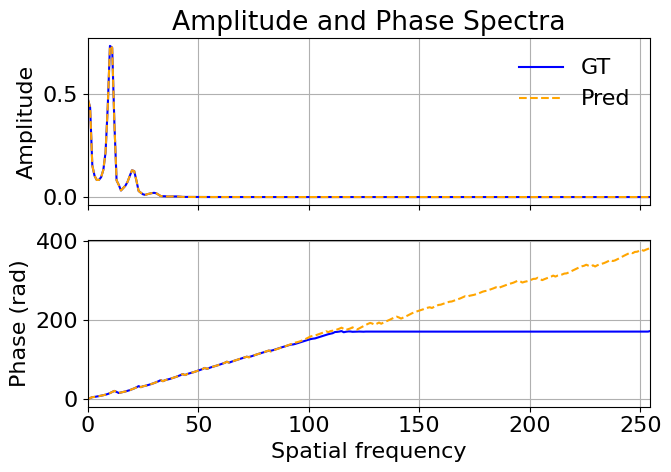

In [588]:
t_loc = 150
print("time:",t_loc/200)
res = compare_spectra_spatial(GT_reshape[:,t_loc], preds_reshape[:,t_loc], x=None, nfft=None, window='hann', plot_phase=True)

#### Calculating the gradient and laplacian of predictions

In [19]:
def compute_grad_laplacian(u,x_range=(-1,1),t_range=(0,1)):
    Nx, Nt = u.shape
    x_min, x_max = x_range
    t_min, t_max = t_range

    dx = (x_max - x_min)/(Nx-1)
    dt = (t_max - t_min)/(Nt-1)

    du_dx, du_dt = np.gradient(u, dx, dt, edge_order=2)
    d2u_dx2, _ = np.gradient(du_dx, dx, dt, edge_order=2)
    _, d2u_dt2 = np.gradient(du_dt, dx, dt, edge_order=2)

    laplacian = d2u_dx2 + d2u_dt2

    grad = np.stack((du_dx, du_dt), axis=-1)

    return grad, laplacian

In [20]:
grad_GT, laplacian_GT = compute_grad_laplacian(GT_reshape)

grad_mag_GT = np.sqrt(grad_GT[:,:,0]**2 + grad_GT[:,:,1]**2).T

In [21]:
grad, laplacian = compute_grad_laplacian(preds_reshape)

print(grad.shape)

(510, 200, 2)


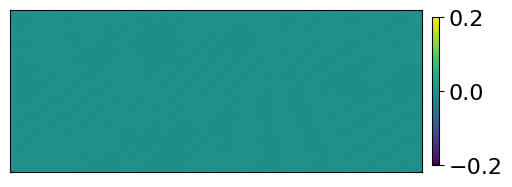

In [22]:
plt.imshow(GT_reshape.T - preds_reshape.T, vmin=-0., vmax=0.2)
plt.xticks([])
plt.yticks([])
plt.colorbar(shrink=0.4, pad=0.02)

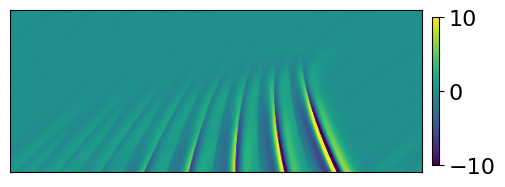

In [38]:
plt.imshow(grad_mag_GT - np.sqrt(grad[:,:,0]**2 + grad[:,:,1]**2).T, vmin=-10, vmax=10)
plt.xticks([])
plt.yticks([])
plt.colorbar(shrink=0.4, pad=0.02)

In [571]:
######### Gradients and Laplacian errors
print(laplacian_GT.shape)

grad_mag_pred = np.sqrt(grad[:,:,0]**2 + grad[:,:,1]**2)

grad_error = np.mean(np.abs(grad_mag_GT - grad_mag_pred.T))
grad_rel_error = np.linalg.norm(grad_mag_GT - grad_mag_pred.T)/(np.linalg.norm(grad_mag_GT))

print("grad_error:",grad_error)
print("grad_rel_error:",grad_rel_error)

laplacian_error = np.mean(np.abs(laplacian_GT - laplacian))
laplacian_rel_error = np.linalg.norm(laplacian_GT - laplacian)/(np.linalg.norm(laplacian_GT))

print("Laplacian_error:",laplacian_error)
print("Laplacian_rel_error:",laplacian_rel_error)

(510, 200)
grad_error: 0.0021298908815562266
grad_rel_error: 0.00022636314612098168
Laplacian_error: 0.1804652127285826
Laplacian_rel_error: 0.000446557518131901


#### If adaptive activation functions

In [246]:
for i, layer in enumerate(model.layers):
    if hasattr(layer, "w0"):
        if isinstance(layer.w0, torch.nn.Parameter):
            print(f"Layer {i} learned w0 = {layer.w0.item():.6f}")
        else:
            print(f"Layer {i} fixed w0 = {layer.w0}")

Layer 0 learned w0 = 1.109672
Layer 1 learned w0 = 1.328750
Layer 2 learned w0 = 1.386923
Layer 3 learned w0 = 1.424030
Layer 4 learned w0 = 1.458883
Layer 5 learned w0 = 1.752529


### Barron norm

In [130]:
def barron_norm_time(signal_2d):
    """
    Args:
        signal_2d: np.ndarray of shape (N_space, N_time)

    Returns:
        norms: np.ndarray of shape (N_space,)
    """
    N_space, N_time = signal_2d.shape
    freqs = np.fft.fftshift(np.fft.fftfreq(N_time))
    norms = np.zeros(N_space)

    for i in range(N_space):
        F = np.fft.fftshift(np.fft.fft(signal_2d[i]))
        norms[i] = np.sum(np.abs(freqs) * np.abs(F)) / N_time

    return norms

def barron_norm_space(signal_2d):
    """
    Args:
        signal_2d: np.ndarray of shape (N_space, N_time)

    Returns:
        norms: np.ndarray of shape (N_time,)
    """
    N_space, N_time = signal_2d.shape
    freqs = np.fft.fftshift(np.fft.fftfreq(N_space))
    norms = np.zeros(N_time)

    for i in range(N_time):
        F = np.fft.fftshift(np.fft.fft(signal_2d[:,i]))
        norms[i] = np.sum(np.abs(freqs) * np.abs(F)) / N_space

    return norms

Text(0, 0.5, '$\\|f\\|_B$')

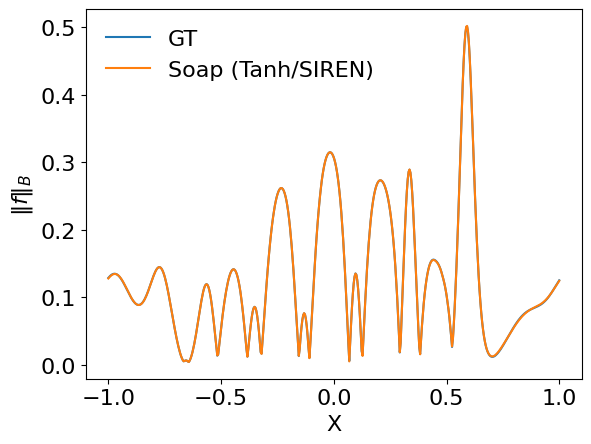

In [131]:
GT_barron_time = barron_norm_time(GT_reshape)
preds_barron_time = barron_norm_time(preds_reshape)

N_space = len(GT_barron_time)
x = np.linspace(-1, 1, N_space)
plt.plot(x,GT_barron_time, label='GT')
plt.plot(x,preds_barron_time, label='Prediction')
plt.legend(frameon=False)
plt.xlabel('X')
plt.ylabel(r'$\|f\|_B$')

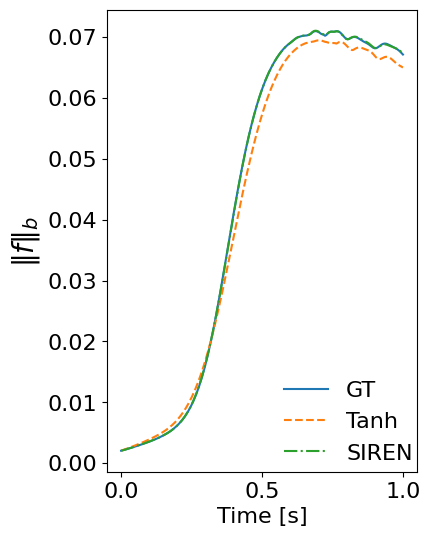

In [133]:
GT_barron_space = barron_norm_space(GT_reshape)
preds_barron_space = barron_norm_space(preds_reshape)
N_time = len(GT_barron_space)

plt.figure(figsize=(4,6))
t = np.linspace(0,1,N_time)
plt.plot(t,GT_barron_space, label='GT')
plt.plot(t,temp_one, label='Tanh', linestyle='--')
plt.plot(t,preds_barron_space, label='SIREN', linestyle='-.')

# plt.plot(t,np.abs(GT_barron_space-preds_barron_space), label='Error',linestyle='-.')
plt.xlabel('Time [s]')
plt.ylabel(r'$\|f\|_b$', fontsize=20)

# plt.yscale('log')
# plt.ylim([5e-9,0.1])
plt.legend(frameon=False,loc='lower right',bbox_to_anchor=(1.05,-0.025))

In [99]:
mean_barron_error = np.mean(np.abs(GT_barron_space- preds_barron_space))
mean_barron_rel_error = np.linalg.norm(GT_barron_space - preds_barron_space)/(np.linalg.norm(GT_barron_space))

print("mean_barron_error:",mean_barron_error)
print("mean_barron_rel_error:",mean_barron_rel_error)

mean_barron_error: 8.714816048469187e-06
mean_barron_rel_error: 0.00024611240209934356


### First, Second, Third, Fourth moments of GT and predictions

In [493]:
from scipy.stats import skew, kurtosis

# gt: shape (510, 200)
# pred: shape (510, 200)

def compute_moments(arr):
    """
    Computes first four statistical moments for each time step.
    Returns an array of shape (T, 4): [mean, variance, skewness, kurtosis].
    """
    mean = np.mean(arr, axis=1)                     # (T,)
    variance = np.var(arr, axis=1)                  # (T,)
    skewness = skew(arr, axis=1)                    # (T,)
    kurt = kurtosis(arr, axis=1, fisher=False)      # (T,)

    # Stack into shape (T, 4)
    moments = np.stack([mean, variance, skewness, kurt], axis=1)
    return moments

gt_moments  = compute_moments(GT_reshape)     # shape (510, 4)
pred_moments = compute_moments(preds_reshape)  # shape (510, 4)

print("gt_moments.shape:",gt_moments.shape)
print("pred_moments.shape:",pred_moments.shape)

gt_moments.shape: (510, 4)
pred_moments.shape: (510, 4)


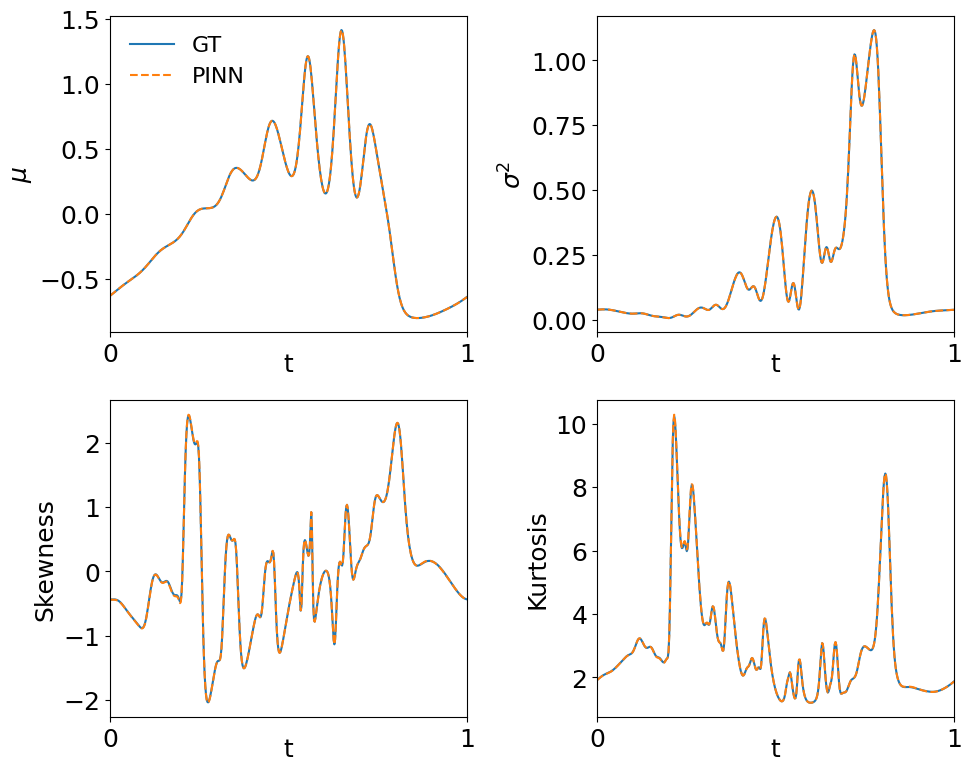

In [494]:
T = gt_moments.shape[0]
t = np.linspace(0, 1, T)

labels = [r"$\mu$", r"$\sigma^2$", "Skewness", "Kurtosis"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    ax.plot(t, gt_moments[:, i], label='GT')
    ax.plot(t, pred_moments[:, i], label='PINN', linestyle='--')

    # ax.set_title(labels[i])
    ax.set_xlabel("t", labelpad=-10, fontsize=18)
    ax.set_ylabel(labels[i], fontsize=18)

    # x-axis only shows 0 and 1
    ax.set_xticks([0, 1])
    ax.set_xlim(0, 1)
    ax.tick_params(axis='both', which='major', labelsize=18)

    if i ==0:
        ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [495]:
pred_moments_average = np.mean(pred_moments,axis=0)
GT_moments_average = np.mean(gt_moments,axis=0)

errors = np.mean(np.abs(pred_moments - gt_moments),axis=0)
print("Mean Absolute errors:",errors)

Mean Absolute errors: [0.0003197  0.0002477  0.00431692 0.00680966]


### Unified frequency error

In [4]:
def frequency_domain_error(pred, gt, L=2.0, ps=[0, 2, 4]):
    """
    Compute frequency-domain weighted errors for given powers p.
    
    Args:
        pred: np.array of shape (T, X), prediction
        gt:   np.array of shape (T, X), ground truth
        L:    float, length of the physical domain (default 1.0)
        ps:   list of exponents p for k^p weighting

    Returns:
        errors: dict mapping p -> log10 of the mean error value
    """
    # 1. Compute error in physical space
    e = pred - gt  # shape (T, X)
    T, X = e.shape  # X is Nx (e.g., 400)

    # 2. Raw Fourier transform along spatial dimension (unnormalized)
    e_hat = np.fft.fft(e, axis=1)  # shape (T, X)

    # 3. Compute Physical Domain Frequency (Wavenumbers)
    # np.fft.fftfreq(X) * X gives integer modes k_int
    # Multiplying by (2 * pi / L) converts to physical wavenumbers
    k_phys = np.fft.fftfreq(X) * X * (2 * np.pi / L)

    errors = {}
    for p in ps:
        # weight by |k_phys|^p
        weight = np.abs(k_phys) ** p  # shape (X,)
        
        # 4. Compute weighted sum over modes
        # We divide by X**2 (Nx**2) to account for Parseval and the Mean
        err_spatial_sum = np.sum(weight * np.abs(e_hat)**2, axis=1) 
        err_mse_per_step = err_spatial_sum / (X**2)
        
        # 5. Average over time steps and apply log10
        errors[p] = np.log10(np.mean(err_mse_per_step) + 1e-15)

    return errors

In [ ]:
F_errors = frequency_domain_error(preds_reshape, GT_reshape)
print(F_errors)